In [7]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from datasets import load_dataset

dataset = load_dataset("turkish_product_reviews")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment'],
        num_rows: 235165
    })
})


In [9]:
import pandas as pd

# Dataset'i pandas'a çevir
df = pd.DataFrame(dataset['train'])

# İlk 5 satıra bak
df.head()

,sentence,sentiment
0,fena değil paraya göre iyi.,1
1,ürün kaliteli ve çok kullanışlı kargo ya veril...,1
2,fiyat-performans karşılaştırması yaptığınızda ...,1
3,bu fiyata çok iyi,1
4,fiyat ve performans olarak gayet iyi,1


In [10]:
# Kaç satır, kaç sütun var?
print("Boyut:", df.shape)

# Sentiment değerleri neler?
print("\nSentiment dağılımı:")
print(df['sentiment'].value_counts())

# Eksik veri var mı?
print("\nEksik veri:")
print(df.isnull().sum())

Boyut: (235165, 2)

Sentiment dağılımı:
sentiment
1    220284
0     14881
Name: count, dtype: int64

Eksik veri:
sentence     0
sentiment    0
dtype: int64


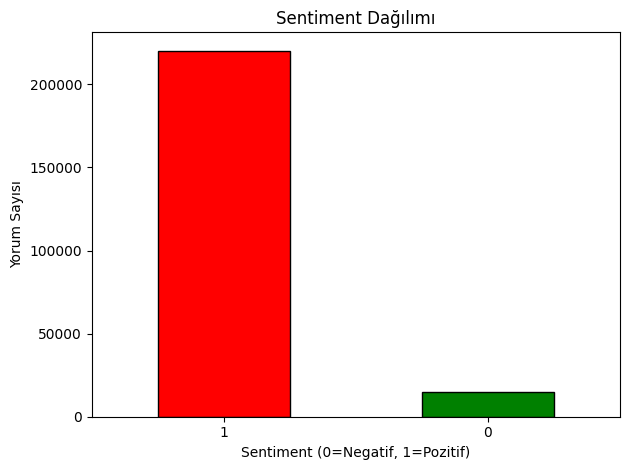

In [11]:
import matplotlib.pyplot as plt

# Dağılım grafiği
df['sentiment'].value_counts().plot(
    kind='bar',
    color=['red', 'green'],
    edgecolor='black'
)

plt.title('Sentiment Dağılımı')
plt.xlabel('Sentiment (0=Negatif, 1=Pozitif)')
plt.ylabel('Yorum Sayısı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Her yorumun kaç karakter olduğunu hesapla
df['yorum_uzunlugu'] = df['sentence'].str.len()

# Ortalama, min, max
print("Yorum uzunluğu istatistikleri:")
print(df.groupby('sentiment')['yorum_uzunlugu'].describe())

Yorum uzunluğu istatistikleri:
              count        mean         std  min   25%    50%    75%     max
sentiment                                                                   
0           14881.0  159.558565  135.031019  0.0  66.0  130.0  208.0  1976.0
1          220284.0  157.698984  137.032544  0.0  64.0  133.0  202.0  2096.0


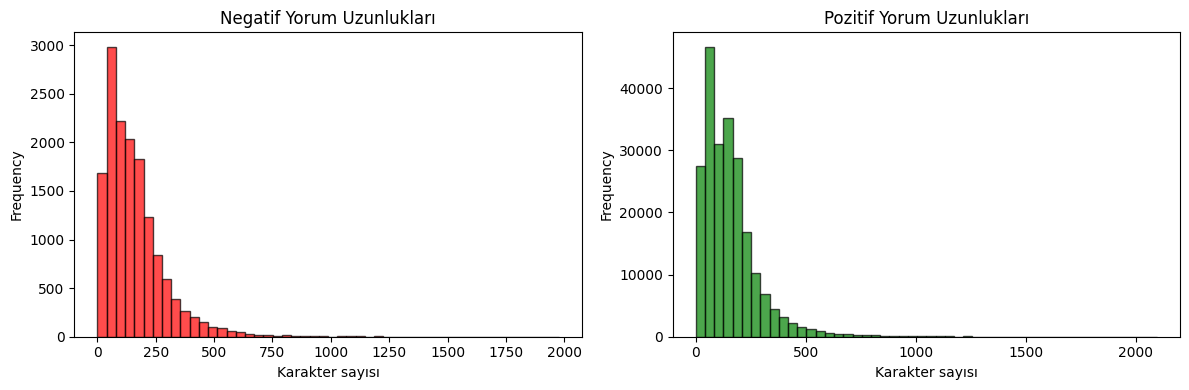

In [13]:
# Pozitif ve negatif yorumların uzunluk dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['sentiment']==0]['yorum_uzunlugu'].plot(
    kind='hist', bins=50, ax=axes[0], 
    color='red', alpha=0.7, edgecolor='black'
)
axes[0].set_title('Negatif Yorum Uzunlukları')
axes[0].set_xlabel('Karakter sayısı')

df[df['sentiment']==1]['yorum_uzunlugu'].plot(
    kind='hist', bins=50, ax=axes[1], 
    color='green', alpha=0.7, edgecolor='black'
)
axes[1].set_title('Pozitif Yorum Uzunlukları')
axes[1].set_xlabel('Karakter sayısı')

plt.tight_layout()
plt.show()

In [14]:
!pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


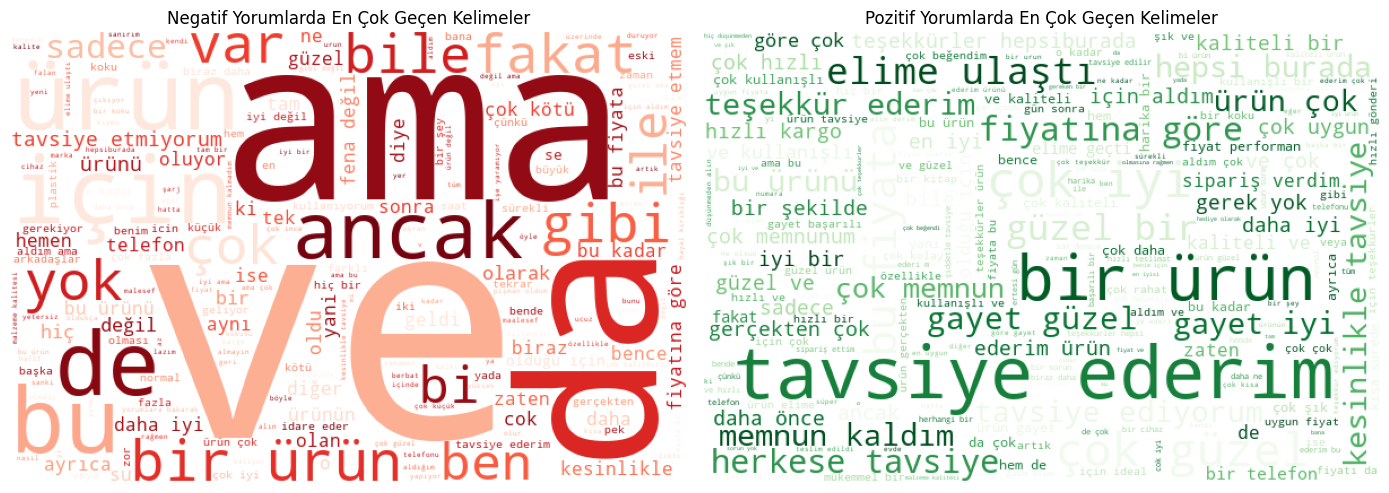

In [15]:
from wordcloud import WordCloud

# Negatif yorumları birleştir
negatif_metin = ' '.join(df[df['sentiment']==0]['sentence'].dropna())

# Pozitif yorumları birleştir
pozitif_metin = ' '.join(df[df['sentiment']==1]['sentence'].dropna())

# Kelime bulutları
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_neg = WordCloud(width=600, height=400, 
                   background_color='white',
                   colormap='Reds').generate(negatif_metin)

wc_pos = WordCloud(width=600, height=400, 
                   background_color='white',
                   colormap='Greens').generate(pozitif_metin)

axes[0].imshow(wc_neg)
axes[0].set_title('Negatif Yorumlarda En Çok Geçen Kelimeler')
axes[0].axis('off')

axes[1].imshow(wc_pos)
axes[1].set_title('Pozitif Yorumlarda En Çok Geçen Kelimeler')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
# En çok geçen 10 kelimeyi bul
from collections import Counter

kelimeler = ' '.join(df['sentence'].dropna()).split()
en_cok = Counter(kelimeler).most_common(10)

for kelime, sayi in en_cok:
    print(f"{kelime}: {sayi}")

bir: 123354
çok: 120382
ve: 113065
bu: 65466
ürün: 61866
için: 47771
tavsiye: 44868
daha: 39908
güzel: 37071
iyi: 36897


In [17]:
import re

def metni_temizle(metin):
    # Küçük harfe çevir
    metin = metin.lower()
    # Noktalama ve sayıları kaldır
    metin = re.sub(r'[^\w\s]', '', metin)
    metin = re.sub(r'\d+', '', metin)
    # Fazla boşlukları kaldır
    metin = metin.strip()
    return metin

# Temizlenmiş sütun ekle
df['temiz_metin'] = df['sentence'].apply(metni_temizle)

# Karşılaştır
print("Orijinal:", df['sentence'][0])
print("Temiz:   ", df['temiz_metin'][0])

Orijinal: fena değil paraya göre iyi.
Temiz:    fena değil paraya göre iyi


In [18]:
# Boş yorumları kaldır
df = df[df['temiz_metin'].str.len() > 0]

print("Temizleme sonrası veri boyutu:", df.shape),


Temizleme sonrası veri boyutu: (235102, 4)


(None,)

In [19]:
from sklearn.model_selection import train_test_split

X = df['temiz_metin']  # Girdi: yorum metni
y = df['sentiment']    # Çıktı: pozitif/negatif

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # %20 test, %80 eğitim
    random_state=42     # Aynı sonucu tekrar almak için
)

print("Eğitim seti:", X_train.shape)
print("Test seti:  ", X_test.shape)

Eğitim seti: (188081,)
Test seti:   (47021,)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Adım 1: Metni sayıya çevir
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Adım 2: Modeli eğit
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Adım 3: Test et
y_pred = model.predict(X_test_tfidf)

# Adım 4: Sonuçları gör
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.32      0.81      0.46      1161
           1       0.99      0.96      0.98     45860

    accuracy                           0.95     47021
   macro avg       0.66      0.88      0.72     47021
weighted avg       0.98      0.95      0.96     47021



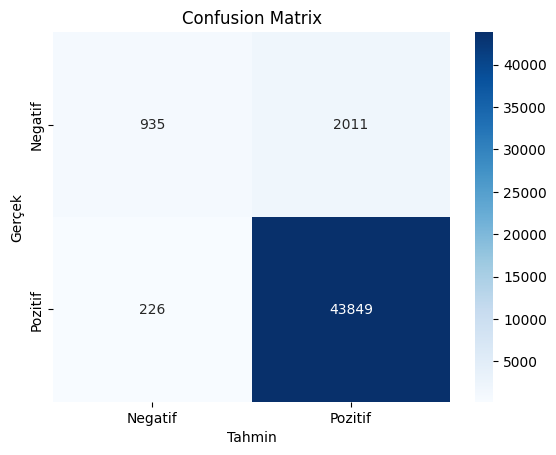

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'])

plt.title('Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

In [ ]:
# Dengeli model
model_dengeli = LogisticRegression(
    max_iter=1000,
    class_weight='balanced' 
)
model_dengeli.fit(X_train_tfidf, y_train)

y_pred_dengeli = model_dengeli.predict(X_test_tfidf)

print(classification_report(y_pred_dengeli, y_test))

              precision    recall  f1-score   support

           0       0.81      0.31      0.44      7790
           1       0.88      0.99      0.93     39231

    accuracy                           0.87     47021
   macro avg       0.84      0.65      0.69     47021
weighted avg       0.87      0.87      0.85     47021



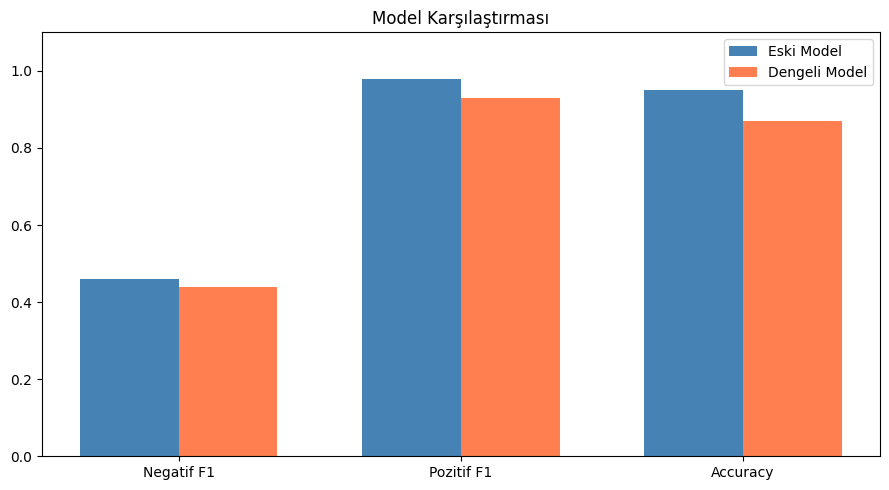

In [23]:
# İki modeli görsel karşılaştır
kategoriler = ['Negatif F1', 'Pozitif F1', 'Accuracy']
eski = [0.46, 0.98, 0.95]
yeni = [0.44, 0.93, 0.87]

x = range(len(kategoriler))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], eski, width, label='Eski Model', color='steelblue')
ax.bar([i + width/2 for i in x], yeni, width, label='Dengeli Model', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(kategoriler)
ax.set_ylim(0, 1.1)
ax.set_title('Model Karşılaştırması')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from imblearn.over_sampling import RandomOverSampler

# Negatifleri çoğalt
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_tfidf, y_train
)

print("Önce:", y_train.value_counts().to_dict())
print("Sonra:", dict(zip(*[['Negatif','Pozitif'], 
      [sum(y_train_balanced==0), sum(y_train_balanced==1)]])))

Önce: {1: 176153, 0: 11928}
Sonra: {'Negatif': 176153, 'Pozitif': 176153}


In [27]:
# Dengeli veriyle yeni model
model_os = LogisticRegression(max_iter=1000)
model_os.fit(X_train_balanced, y_train_balanced)

y_pred_os = model_os.predict(X_test_tfidf)

print(classification_report(y_pred_os, y_test))

              precision    recall  f1-score   support

           0       0.79      0.31      0.44      7527
           1       0.88      0.98      0.93     39494

    accuracy                           0.88     47021
   macro avg       0.84      0.65      0.69     47021
weighted avg       0.87      0.88      0.85     47021



In [28]:
# Daha güçlü TF-IDF + farklı model
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,   # Daha fazla kelime
        ngram_range=(1, 2),   # Tek kelime + ikili kelime grupları
        min_df=2
    )),
    ('model', LinearSVC(
        class_weight='balanced',
        max_iter=2000
    ))
])

pipeline.fit(X_train, y_train)
y_pred_svm = pipeline.predict(X_test)

print(classification_report(y_pred_svm, y_test))

              precision    recall  f1-score   support

           0       0.68      0.43      0.53      4629
           1       0.94      0.98      0.96     42392

    accuracy                           0.92     47021
   macro avg       0.81      0.70      0.74     47021
weighted avg       0.91      0.92      0.92     47021

